# 05 - Forecast Evaluation｜預測誤差與偏差分析

## 分析目的

本 Notebook 延續 `04_order_forecasting.ipynb`，不重新訓練模型，而是深入檢查最佳 Forecast 方法的：

- Forecast Error
- Forecast Bias
- Horizon Risk
- Fold Stability
- Worst-case Error
- Historical Error Distribution
- Planning Reference Range

04 已回答：

> 哪一個模型在 Rolling Backtest 中表現最好？

05 進一步回答：

> 這個最佳模型通常怎麼錯、哪一個 Horizon 最容易失準、哪個期間最難預測，以及 Planner 使用 Forecast 時應保留多少不確定性？

## Error 定義

本 Notebook 使用：

`Forecast Error = Prediction - Actual`

因此：

- Error > 0：**Over-Forecast**
- Error < 0：**Under-Forecast**
- Error = 0：Forecast 與 Actual 完全相同

## 重要限制

### 1. 05 不重新調整模型

本 Notebook 只評估 04 已完成的 out-of-sample predictions，不利用 05 的 Error Analysis 重新挑選一個分數更漂亮的模型。

### 2. Planning Reference 不是 Prediction Interval

後面使用 Backtest 的 Absolute Percentage Error 建立簡單的 Planning Reference Range。

它不是：

- 95% Confidence Interval
- 80% Prediction Interval
- 未來需求機率分布

只代表近期 Rolling Backtest 中實際觀察到的歷史誤差尺度。


## Step 1｜載入 Evaluation 套件

### 這一格要做什麼？

載入：

- `Path`：處理專案路徑
- `numpy`：數值與 percentile 計算
- `pandas`：Forecast Error Analysis
- `matplotlib`：誤差圖表
- `display`：顯示分析表格

### 為什麼不需要重新載入 XGBoost 或 Holt-Winters？

模型訓練與 Backtest 已在 04 完成。05 只讀取正式保存的 Prediction Results，因此不需要重新建立任何 Forecast Model。


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

print("Evaluation libraries loaded successfully.")


Evaluation libraries loaded successfully.


### 輸出解讀

實際輸出：

```text
Evaluation libraries loaded successfully.
```

代表資料分析與圖表套件均成功載入。

**白話解讀：** 05 的環境已準備完成，可以直接讀取 04 保存的 Forecast 與 Backtest 結果。

**下一步：**讀取 Model Summary、72 筆 Backtest Predictions 與最終 3 個月 Forecast。


## Step 2｜讀取 04 Forecast 正式輸出

### 這一格要做什麼？

讀取：

- `order_forecast_backtest_predictions.csv`
- `order_forecast_model_summary.csv`
- `final_3_month_order_forecast.csv`
- `order_forecast_planner_summary.csv`

### 為什麼直接使用 04 的輸出？

05 的任務是評估已完成的 out-of-sample Forecast。直接讀取 04 保存的正式結果，可以確保模型排名、Prediction 與 Final Forecast 前後一致，不會在 Evaluation 階段重新產生另一套結果。


In [2]:
PROJECT_ROOT = Path.cwd().parent
REPORT_TABLE_DIR = PROJECT_ROOT / "reports" / "tables"

BACKTEST_PATH = (
    REPORT_TABLE_DIR
    / "order_forecast_backtest_predictions.csv"
)

MODEL_SUMMARY_PATH = (
    REPORT_TABLE_DIR
    / "order_forecast_model_summary.csv"
)

FINAL_FORECAST_PATH = (
    REPORT_TABLE_DIR
    / "final_3_month_order_forecast.csv"
)

PLANNER_SUMMARY_PATH = (
    REPORT_TABLE_DIR
    / "order_forecast_planner_summary.csv"
)

required_paths = [
    BACKTEST_PATH,
    MODEL_SUMMARY_PATH,
    FINAL_FORECAST_PATH,
    PLANNER_SUMMARY_PATH,
]

missing_files = [
    str(path)
    for path in required_paths
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Required 04 outputs are missing:\n"
        + "\n".join(missing_files)
    )

backtest_predictions = pd.read_csv(
    BACKTEST_PATH,
    parse_dates=[
        "forecast_origin",
        "forecast_date",
    ],
)

model_summary = pd.read_csv(
    MODEL_SUMMARY_PATH
)

final_forecast = pd.read_csv(
    FINAL_FORECAST_PATH,
    parse_dates=["date"],
)

planner_summary_04 = pd.read_csv(
    PLANNER_SUMMARY_PATH
)

print(
    "Backtest rows:",
    len(backtest_predictions),
)

print(
    "Models:",
    sorted(
        backtest_predictions["model"]
        .unique()
        .tolist()
    ),
)

display(
    model_summary
    .sort_values("wape_pct")
    .round(3)
)

display(
    final_forecast.round(
        {
            column: 2
            for column in final_forecast.columns
            if column != "date"
        }
    )
)


Backtest rows: 72
Models: ['holt_winters', 'last_value', 'seasonal_naive', 'xgboost_direct']


,model,mae,wape_pct,smape_pct,mean_fold_wape_pct,std_fold_wape_pct
0,last_value,98.778,1.851,1.862,1.848,0.852
1,holt_winters,106.288,1.991,2.008,1.988,1.013
2,xgboost_direct,222.218,4.164,4.229,4.141,1.060
3,seasonal_naive,398.722,7.471,7.728,7.437,1.078


,date,last_value,seasonal_naive,holt_winters,xgboost_direct,selected_forecast
0,2026-09-01,5769.0,5132.0,5771.39,5621.55,5769.0
1,2026-10-01,5769.0,5264.0,5796.20,5620.90,5769.0
2,2026-11-01,5769.0,5288.0,5803.92,5616.26,5769.0


### 輸出解讀

實際讀取結果：

```text
Backtest rows: 72
Models:
['holt_winters', 'last_value', 'seasonal_naive', 'xgboost_direct']
```

Model Summary：

| Model | WAPE | MAE |
|---|---:|---:|
| **Last Value** | **1.851%** | **98.778** |
| Holt-Winters | 1.991% | 106.288 |
| XGBoost Direct | 4.164% | 222.218 |
| Seasonal Naive | 7.471% | 398.722 |

Final Forecast：

| Month | Last Value | Holt-Winters | XGBoost | Seasonal Naive | Selected |
|---|---:|---:|---:|---:|---:|
| 2026-09 | 5,769 | 5,771.39 | 5,621.55 | 5,132 | **5,769** |
| 2026-10 | 5,769 | 5,796.20 | 5,620.90 | 5,264 | **5,769** |
| 2026-11 | 5,769 | 5,803.92 | 5,616.26 | 5,288 | **5,769** |

**白話解讀：**

05 成功讀到與 04 一致的結果。Last Value 仍是 pooled WAPE 最低的方法，因此後面的 Error / Bias Analysis 會以 `last_value` 的 18 筆 out-of-sample predictions 為主。

**下一步：**確認四個模型的 Backtest 樣本數與時間結構完全一致。


## Step 3｜Evaluation Input Check

### 這一格要做什麼？

確認：

- 必要欄位存在
- Actual / Prediction 沒有 Missing Values
- Horizon 只有 1、2、3
- Fold 只有 1～6
- 每個模型剛好有 18 筆 Prediction
- Actual New Orders 全部大於 0

### 為什麼每個模型必須有 18 筆？

`6 Folds × 3 Horizons = 18`

只有當四個模型都用完全相同的 18 個 Validation Points 比較時，Error 與 Bias 才具有公平性。


In [3]:
required_columns = {
    "fold",
    "forecast_origin",
    "model",
    "horizon",
    "forecast_date",
    "actual",
    "prediction",
}

missing_columns = (
    required_columns
    - set(backtest_predictions.columns)
)

if missing_columns:
    raise ValueError(
        f"Missing columns: {sorted(missing_columns)}"
    )

if backtest_predictions[
    ["actual", "prediction"]
].isna().any().any():
    raise ValueError(
        "Backtest contains missing actual or prediction values."
    )

if (
    backtest_predictions["actual"] <= 0
).any():
    raise ValueError(
        "Actual New Orders must be positive for percentage error analysis."
    )

expected_horizons = {1, 2, 3}
actual_horizons = set(
    backtest_predictions["horizon"].unique()
)

if actual_horizons != expected_horizons:
    raise ValueError(
        f"Unexpected horizons: {sorted(actual_horizons)}"
    )

expected_folds = set(range(1, 7))
actual_folds = set(
    backtest_predictions["fold"].unique()
)

if actual_folds != expected_folds:
    raise ValueError(
        f"Unexpected folds: {sorted(actual_folds)}"
    )

rows_per_model = (
    backtest_predictions
    .groupby("model")
    .size()
)

if not rows_per_model.eq(18).all():
    raise ValueError(
        "Each model must have exactly 18 backtest predictions."
    )

best_model_name = str(
    model_summary
    .sort_values("wape_pct")
    .iloc[0]["model"]
)

print("EVALUATION INPUT CHECK: PASS")
print("Selected model:", best_model_name)
print()
print("Rows per model:")
print(rows_per_model)


EVALUATION INPUT CHECK: PASS
Selected model: last_value

Rows per model:
model
holt_winters      18
last_value        18
seasonal_naive    18
xgboost_direct    18
dtype: int64


### 輸出解讀

實際輸出：

```text
EVALUATION INPUT CHECK: PASS
Selected model: last_value
```

每個模型都具有：

```text
18 predictions
```

因此：

- 4 models × 18 = 72 rows
- 6 Folds × 3 Horizons 結構完整
- 沒有模型少掉某一個 Validation Point

**白話解讀：** 05 的所有模型比較與 Error Analysis 使用一致的 out-of-sample 驗證樣本，可以繼續分析 Selected Model 的誤差方向。

**下一步：**把 Last Value 的 18 筆 Prediction 拆成 Signed Error、Percentage Error 與 Error Direction。


## Step 4｜建立 Selected Model 的逐筆 Forecast Error

### 這一格要做什麼？

針對 `last_value` 的每一筆 out-of-sample prediction 建立：

- `error = prediction - actual`
- `absolute_error`
- `percentage_error`
- `absolute_percentage_error`
- `error_direction`

### Error Direction

- `Over-Forecast`：Prediction > Actual
- `Under-Forecast`：Prediction < Actual
- `Exact`：Prediction = Actual

### 為什麼 Signed Error 很重要？

WAPE 只衡量「錯多少」，不表示「通常往哪個方向錯」。

對 Planner 而言，持續低估需求與持續高估需求代表不同的規劃風險，因此 Bias 必須另外分析。


In [4]:
selected_predictions = (
    backtest_predictions.loc[
        backtest_predictions["model"]
        .eq(best_model_name)
    ]
    .copy()
    .sort_values(
        ["forecast_date", "horizon"]
    )
    .reset_index(drop=True)
)

selected_predictions["error"] = (
    selected_predictions["prediction"]
    - selected_predictions["actual"]
)

selected_predictions["absolute_error"] = (
    selected_predictions["error"].abs()
)

selected_predictions[
    "percentage_error"
] = (
    selected_predictions["error"]
    / selected_predictions["actual"]
    * 100
)

selected_predictions[
    "absolute_percentage_error"
] = (
    selected_predictions[
        "percentage_error"
    ].abs()
)

selected_predictions[
    "error_direction"
] = np.select(
    [
        selected_predictions["error"] > 0,
        selected_predictions["error"] < 0,
    ],
    [
        "Over-Forecast",
        "Under-Forecast",
    ],
    default="Exact",
)

display(
    selected_predictions[
        [
            "fold",
            "forecast_origin",
            "horizon",
            "forecast_date",
            "actual",
            "prediction",
            "error",
            "percentage_error",
            "error_direction",
        ]
    ].round(
        {
            "actual": 2,
            "prediction": 2,
            "error": 2,
            "percentage_error": 2,
        }
    )
)


,fold,forecast_origin,horizon,forecast_date,actual,prediction,error,percentage_error,error_direction
0,1,2025-02-01,1,2025-03-01,5147.0,4927.0,-220.0,-4.27,Under-Forecast
1,1,2025-02-01,2,2025-04-01,4978.0,4927.0,-51.0,-1.02,Under-Forecast
2,1,2025-02-01,3,2025-05-01,5148.0,4927.0,-221.0,-4.29,Under-Forecast
3,2,2025-05-01,1,2025-06-01,5192.0,5148.0,-44.0,-0.85,Under-Forecast
4,2,2025-05-01,2,2025-07-01,5202.0,5148.0,-54.0,-1.04,Under-Forecast
5,2,2025-05-01,3,2025-08-01,5158.0,5148.0,-10.0,-0.19,Under-Forecast
6,3,2025-08-01,1,2025-09-01,5132.0,5158.0,26.0,0.51,Over-Forecast
7,3,2025-08-01,2,2025-10-01,5264.0,5158.0,-106.0,-2.01,Under-Forecast
8,3,2025-08-01,3,2025-11-01,5288.0,5158.0,-130.0,-2.46,Under-Forecast
9,4,2025-11-01,1,2025-12-01,5293.0,5288.0,-5.0,-0.09,Under-Forecast


### 輸出解讀

18 筆 Last Value Backtest Prediction 中：

- 大多數 Error 都是負值。
- 唯一的 Over-Forecast 發生在 **2025-09**：
  - Actual = 5,132
  - Prediction = 5,158
  - Error = +26
  - Percentage Error = +0.51%

其餘 17 筆都是 Under-Forecast。

最大幾個負 Error 包含：

- 2025-05：-221
- 2025-03：-220
- 2026-05：-231
- 2026-08：-190

**白話解讀：**

近期 Validation Period 的 Actual New Orders 整體呈上升方向，而 Last Value 的方法是沿用 Forecast Origin 當月水準。因此在需求上升期間，預測值通常會落在後續 Actual 下方。

這已經顯示出明顯的 Under-Forecast 傾向，但是否屬於整體 Bias 仍需下一格統計所有 18 筆 Prediction。

**下一步：**計算 Overall Mean Error、Aggregate Bias 與 Over / Under 次數。


## Step 5｜分析 Overall Forecast Bias

### 這一格要做什麼？

計算：

### Mean Error

`平均(Prediction - Actual)`

- 正值：平均偏高
- 負值：平均偏低

### Aggregate Bias %

`Σ(Prediction - Actual) / ΣActual × 100`

衡量整體 Forecast 總量相對 Actual 總量偏高或偏低多少。

### Over / Under Count

統計 18 筆 Forecast 中：

- Over-Forecast 幾次
- Under-Forecast 幾次

### 為什麼 Bias 和 WAPE 必須分開看？

正 Error 與負 Error 可能互相抵銷，因此 Bias 小不代表模型準；WAPE 小也不代表模型沒有方向性偏差。


In [5]:
mean_error = float(
    selected_predictions["error"].mean()
)

aggregate_bias_pct = float(
    selected_predictions["error"].sum()
    / selected_predictions["actual"].sum()
    * 100
)

mean_absolute_error = float(
    selected_predictions[
        "absolute_error"
    ].mean()
)

mean_absolute_percentage_error = float(
    selected_predictions[
        "absolute_percentage_error"
    ].mean()
)

direction_counts = (
    selected_predictions[
        "error_direction"
    ]
    .value_counts()
    .reindex(
        [
            "Over-Forecast",
            "Under-Forecast",
            "Exact",
        ],
        fill_value=0,
    )
)

overall_bias_summary = pd.DataFrame(
    {
        "metric": [
            "Selected model",
            "Backtest observations",
            "Mean Error (USD mn)",
            "Aggregate Bias",
            "Mean Absolute Error (USD mn)",
            "Mean Absolute Percentage Error",
            "Over-Forecast count",
            "Under-Forecast count",
            "Exact count",
        ],
        "value": [
            best_model_name,
            len(selected_predictions),
            round(mean_error, 2),
            f"{aggregate_bias_pct:.2f}%",
            round(mean_absolute_error, 2),
            (
                f"{mean_absolute_percentage_error:.2f}%"
            ),
            int(
                direction_counts[
                    "Over-Forecast"
                ]
            ),
            int(
                direction_counts[
                    "Under-Forecast"
                ]
            ),
            int(
                direction_counts["Exact"]
            ),
        ],
    }
)

display(overall_bias_summary)

print()
if aggregate_bias_pct > 0:
    print(
        "Bias direction: overall Over-Forecast."
    )
elif aggregate_bias_pct < 0:
    print(
        "Bias direction: overall Under-Forecast."
    )
else:
    print(
        "Bias direction: no aggregate bias."
    )


,metric,value
0,Selected model,last_value
1,Backtest observations,18
2,Mean Error (USD mn),-95.89
3,Aggregate Bias,-1.80%
4,Mean Absolute Error (USD mn),98.78
5,Mean Absolute Percentage Error,1.84%
6,Over-Forecast count,1
7,Under-Forecast count,17
8,Exact count,0



Bias direction: overall Under-Forecast.


### 輸出解讀

實際結果：

| Metric | Result |
|---|---:|
| Selected Model | **last_value** |
| Backtest Observations | **18** |
| Mean Error | **-95.89 百萬美元** |
| Aggregate Bias | **-1.80%** |
| Mean Absolute Error | **98.78 百萬美元** |
| Mean Absolute Percentage Error | **1.84%** |
| Over-Forecast | **1** |
| Under-Forecast | **17** |
| Exact | **0** |

程式判讀：

```text
Bias direction: overall Under-Forecast.
```

### 白話解讀

Last Value 雖然在 04 的 pooled WAPE 最低，但具有非常明顯的方向性：

> 18 筆 Forecast 中有 17 筆低於 Actual。

平均每筆 Prediction 比 Actual 少約 **95.89 百萬美元**，整體總量 Bias 約 **-1.80%**。

這表示目前的最佳模型是「整體誤差小」，但不代表「沒有偏差」。在近期 New Orders 上升的 Validation Period 中，Last Value 容易低估後續需求。

### Planner 意義

若直接把 Last Value 點預測當成唯一需求數字，近期成長環境下可能低估需求壓力。因此後續 Planning Scenario 不宜只看 Point Forecast，也需要保留上方需求緩衝。

**下一步：**檢查這個 Under-Forecast Bias 是否隨 H1 → H3 變得更明顯。


## Step 6｜分析 Horizon 1 / 2 / 3 的 Error 與 Bias

### 這一格要做什麼？

分別對 H1、H2、H3 計算：

- Observation Count
- Mean Error
- MAE
- MAPE
- Aggregate Bias
- Over-Forecast Count
- Under-Forecast Count

### 為什麼需要 Horizon Analysis？

04 已顯示 H3 的 WAPE 高於 H1 / H2。

這一格進一步判斷：

> Forecast 距離越遠時，是只有誤差變大，還是 Under-Forecast Bias 也同步增加？


In [6]:
horizon_records = []

for horizon, group in (
    selected_predictions
    .groupby("horizon")
):

    horizon_records.append(
        {
            "horizon": int(horizon),
            "observations": len(group),
            "mean_error": (
                group["error"].mean()
            ),
            "mae": (
                group[
                    "absolute_error"
                ].mean()
            ),
            "mape_pct": (
                group[
                    "absolute_percentage_error"
                ].mean()
            ),
            "aggregate_bias_pct": (
                group["error"].sum()
                / group["actual"].sum()
                * 100
            ),
            "over_count": int(
                (
                    group[
                        "error_direction"
                    ]
                    == "Over-Forecast"
                ).sum()
            ),
            "under_count": int(
                (
                    group[
                        "error_direction"
                    ]
                    == "Under-Forecast"
                ).sum()
            ),
        }
    )

horizon_bias = pd.DataFrame(
    horizon_records
)

display(
    horizon_bias.round(
        {
            "mean_error": 2,
            "mae": 2,
            "mape_pct": 2,
            "aggregate_bias_pct": 2,
        }
    )
)


,horizon,observations,mean_error,mae,mape_pct,aggregate_bias_pct,over_count,under_count
0,1,6,-65.00,73.67,1.39,-1.22,1,5
1,2,6,-82.33,82.33,1.53,-1.55,0,6
2,3,6,-140.33,140.33,2.58,-2.61,0,6


### 輸出解讀

實際 Horizon 結果：

| Horizon | Mean Error | MAE | MAPE | Aggregate Bias | Over | Under |
|---|---:|---:|---:|---:|---:|---:|
| H1 | -65.00 | 73.67 | 1.39% | **-1.22%** | 1 | 5 |
| H2 | -82.33 | 82.33 | 1.53% | **-1.55%** | 0 | 6 |
| H3 | -140.33 | 140.33 | 2.58% | **-2.61%** | 0 | 6 |

### 白話解讀

Forecast Horizon 越遠，誤差與 Under-Forecast Bias 都變大：

- H1 Bias：-1.22%
- H2 Bias：-1.55%
- H3 Bias：-2.61%

H3 的平均絕對誤差 **140.33 百萬美元**，幾乎是 H1 的兩倍。

而且：

- H2 六筆全部 Under-Forecast
- H3 六筆全部 Under-Forecast

**Planner 意義：**

3 個月 ahead 的 Forecast 不只歷史誤差較大，也更容易低估需求。因此 H3 不應和 H1 使用相同程度的信心。

### 限制

每個 Horizon 只有 6 筆 out-of-sample observations，因此結果屬於描述性證據，不應視為長期統計定律。

**下一步：**分析 6 個時間 Fold，找出哪一段期間最難預測。


## Step 7｜分析各 Fold 的 Forecast Error / Bias

### 這一格要做什麼？

每個 Fold 包含連續 3 個 Validation Months。

計算：

- Forecast Origin
- Validation Start / End
- WAPE
- Mean Error
- Aggregate Bias
- MAE

### 為什麼看 Fold？

不同時間區間可能具有不同需求型態。Fold Analysis 可以確認模型是否只在某一段時間突然失準，以及 pooled WAPE 是否掩蓋特定期間的大誤差。


In [7]:
fold_records = []

for fold, group in (
    selected_predictions
    .groupby("fold")
):

    fold_records.append(
        {
            "fold": int(fold),
            "forecast_origin": (
                group[
                    "forecast_origin"
                ].iloc[0]
            ),
            "validation_start": (
                group[
                    "forecast_date"
                ].min()
            ),
            "validation_end": (
                group[
                    "forecast_date"
                ].max()
            ),
            "wape_pct": (
                group[
                    "absolute_error"
                ].sum()
                / group["actual"].sum()
                * 100
            ),
            "mean_error": (
                group["error"].mean()
            ),
            "aggregate_bias_pct": (
                group["error"].sum()
                / group["actual"].sum()
                * 100
            ),
            "mae": (
                group[
                    "absolute_error"
                ].mean()
            ),
        }
    )

fold_evaluation = (
    pd.DataFrame(
        fold_records
    )
    .sort_values("fold")
)

display(
    fold_evaluation.round(
        {
            "wape_pct": 3,
            "mean_error": 2,
            "aggregate_bias_pct": 2,
            "mae": 2,
        }
    )
)

worst_fold = (
    fold_evaluation
    .sort_values(
        "wape_pct",
        ascending=False,
    )
    .iloc[0]
)

print()
print(
    "Worst fold by WAPE:",
    int(worst_fold["fold"]),
)

print(
    "Worst-fold WAPE:",
    f"{worst_fold['wape_pct']:.3f}%",
)


,fold,forecast_origin,validation_start,validation_end,wape_pct,mean_error,aggregate_bias_pct,mae
0,1,2025-02-01,2025-03-01,2025-05-01,3.221,-164.00,-3.22,164.00
1,2,2025-05-01,2025-06-01,2025-08-01,0.694,-36.00,-0.69,36.00
2,3,2025-08-01,2025-09-01,2025-11-01,1.670,-70.00,-1.34,87.33
3,4,2025-11-01,2025-12-01,2026-02-01,0.992,-53.00,-0.99,53.00
4,5,2026-02-01,2026-03-01,2026-05-01,2.111,-115.33,-2.11,115.33
5,6,2026-05-01,2026-06-01,2026-08-01,2.397,-137.00,-2.40,137.00



Worst fold by WAPE: 1
Worst-fold WAPE: 3.221%


### 輸出解讀

各 Fold 結果：

| Fold | Validation | WAPE | Mean Error | Bias |
|---|---|---:|---:|---:|
| 1 | 2025-03～2025-05 | **3.221%** | -164.00 | -3.22% |
| 2 | 2025-06～2025-08 | **0.694%** | -36.00 | -0.69% |
| 3 | 2025-09～2025-11 | **1.670%** | -70.00 | -1.34% |
| 4 | 2025-12～2026-02 | **0.992%** | -53.00 | -0.99% |
| 5 | 2026-03～2026-05 | **2.111%** | -115.33 | -2.11% |
| 6 | 2026-06～2026-08 | **2.397%** | -137.00 | -2.40% |

Worst Fold：

```text
Fold 1
WAPE = 3.221%
```

### 白話解讀

Fold 1 是 Last Value 最難預測的三個月期間，平均每月低估約 **164 百萬美元**。

Fold 2 與 Fold 4 相對容易，WAPE 都低於 1%。

另外值得注意的是：

- 6 個 Fold 的 Mean Error 全部為負值。
- 即使 Fold 3 含有唯一一筆 Over-Forecast，整個 Fold 合計仍然是 Under-Forecast。

因此方向性 Bias 並不是只由單一 Fold 造成。

### 重要修正

04 的圖中 Fold 6 並不是 Last Value 最差 Fold；真正最差的是 **Fold 1 = 3.221%**。Fold 6 的 2.397% 是第二高。

**下一步：**直接找出 18 筆 Prediction 中最差的單月案例。


## Step 8｜找出最大的單月 Forecast Error

### 這一格要做什麼？

依 `Absolute Percentage Error` 從大到小排序，列出最差的 5 筆 Prediction。

### 分析目的

確認：

- 最大誤差發生在哪些月份
- 是否集中在 H3
- 是否集中於特定 Fold
- Error Direction 是否一致

### 為什麼需要 Case-level Analysis？

平均 WAPE 可能掩蓋個別大誤差。Planner 在實際使用時，也需要知道歷史 Backtest 中最差單月大概錯到什麼程度。


In [8]:
worst_predictions = (
    selected_predictions
    .sort_values(
        "absolute_percentage_error",
        ascending=False,
    )
    .head(5)
    [
        [
            "fold",
            "forecast_origin",
            "horizon",
            "forecast_date",
            "actual",
            "prediction",
            "error",
            "percentage_error",
            "absolute_percentage_error",
            "error_direction",
        ]
    ]
    .copy()
)

display(
    worst_predictions.round(
        {
            "actual": 2,
            "prediction": 2,
            "error": 2,
            "percentage_error": 2,
            "absolute_percentage_error": 2,
        }
    )
)


,fold,forecast_origin,horizon,forecast_date,actual,prediction,error,percentage_error,absolute_percentage_error,error_direction
2,1,2025-02-01,3,2025-05-01,5148.0,4927.0,-221.0,-4.29,4.29,Under-Forecast
0,1,2025-02-01,1,2025-03-01,5147.0,4927.0,-220.0,-4.27,4.27,Under-Forecast
14,5,2026-02-01,3,2026-05-01,5579.0,5348.0,-231.0,-4.14,4.14,Under-Forecast
17,6,2026-05-01,3,2026-08-01,5769.0,5579.0,-190.0,-3.29,3.29,Under-Forecast
8,3,2025-08-01,3,2025-11-01,5288.0,5158.0,-130.0,-2.46,2.46,Under-Forecast


### 輸出解讀

最差 5 筆 Prediction：

| Forecast Date | Horizon | APE | Error Direction |
|---|---:|---:|---|
| 2025-05 | H3 | **4.29%** | Under |
| 2025-03 | H1 | **4.27%** | Under |
| 2026-05 | H3 | **4.14%** | Under |
| 2026-08 | H3 | **3.29%** | Under |
| 2025-11 | H3 | **2.46%** | Under |

最大單月 Error：

- 2025-05
- Actual = **5,148**
- Prediction = **4,927**
- Error = **-221**
- APE = **4.29%**

### 白話解讀

Top 5 最差案例全部都是 **Under-Forecast**。

其中 **4 / 5** 發生在 H3，支持前一格「3 個月 ahead 最容易失準」的結果。

但最大 APE 只有 4.29%，並不代表未來最大誤差一定不會超過 4.29%；這只是目前 18 筆近期 Backtest 中觀察到的最大值。

**下一步：**用時間圖檢查 Prediction 是否長期落在 Actual 下方。


## Step 9｜繪製 Actual vs Prediction

### 這一格要做什麼？

按照 Forecast Date 繪製：

- Actual New Orders
- Last Value Prediction

### 為什麼需要時間圖？

表格可以看單筆誤差，時間圖則更容易辨識：

- Actual 是否存在持續上升／下降趨勢
- Prediction 是否長時間位於 Actual 上方或下方
- Last Value 在趨勢轉折時是否反應較慢


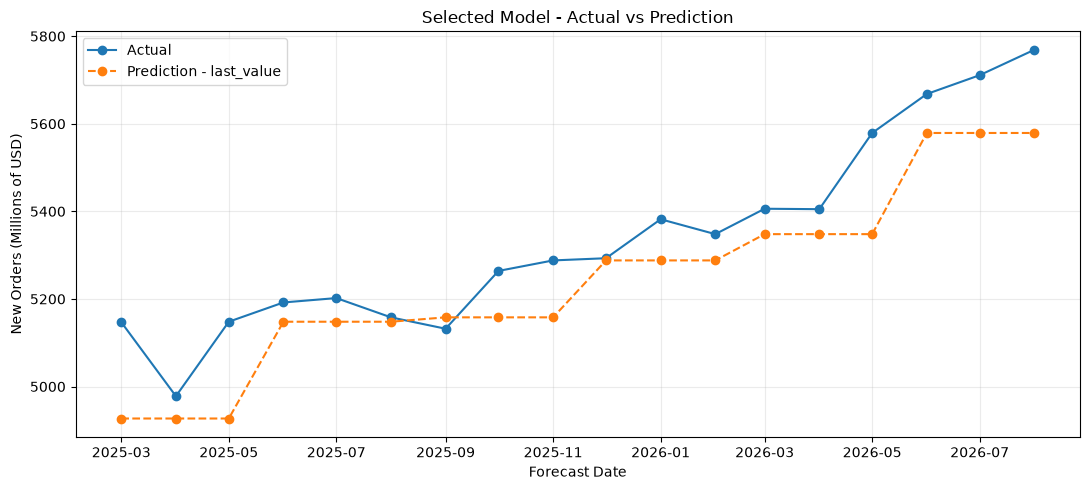

Saved: C:\Users\momo8\Desktop\electronic-components-planning\reports\figures\05_selected_model_actual_vs_prediction.png


In [9]:
plot_data = (
    selected_predictions
    .sort_values("forecast_date")
)

fig, ax = plt.subplots(
    figsize=(11, 5)
)

ax.plot(
    plot_data["forecast_date"],
    plot_data["actual"],
    marker="o",
    label="Actual",
)

ax.plot(
    plot_data["forecast_date"],
    plot_data["prediction"],
    marker="o",
    linestyle="--",
    label=(
        f"Prediction - {best_model_name}"
    ),
)

ax.set_title(
    "Selected Model - Actual vs Prediction"
)
ax.set_xlabel("Forecast Date")
ax.set_ylabel("New Orders (Millions of USD)")
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

REPORT_FIGURE_DIR = (
    PROJECT_ROOT
    / "reports"
    / "figures"
)

REPORT_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

figure_path = (
    REPORT_FIGURE_DIR
    / "05_selected_model_actual_vs_prediction.png"
)

fig.savefig(
    figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print("Saved:", figure_path)


### 輸出解讀

圖表顯示：

- 2025-03 到 2026-08 的 Actual New Orders 整體呈上升趨勢。
- Last Value Prediction 呈現階梯狀，因為每一個 Fold 都沿用 Forecast Origin 的最新水準。
- 除了 2025-09 之外，Prediction 幾乎都位於 Actual 下方。
- 2026 年中後期 Actual 上升較快時，Prediction 與 Actual 的距離再次拉大。

**白話解讀：**

Last Value 對平穩或緩慢變化的短期需求表現很好，但遇到連續上升趨勢時會自然落後 Actual。

這與 17 / 18 筆 Under-Forecast 及 Aggregate Bias -1.80% 完全一致。

**下一步：**使用 Signed Error 圖直接呈現每個月份偏高或偏低多少。


## Step 10｜繪製 Signed Forecast Error

### 這一格要做什麼？

繪製：

`Prediction - Actual`

因此：

- 0 上方：Over-Forecast
- 0 下方：Under-Forecast

### 為什麼需要這張圖？

Signed Error 以 0 為明確基準，可直接觀察模型是否長時間偏向同一方向。


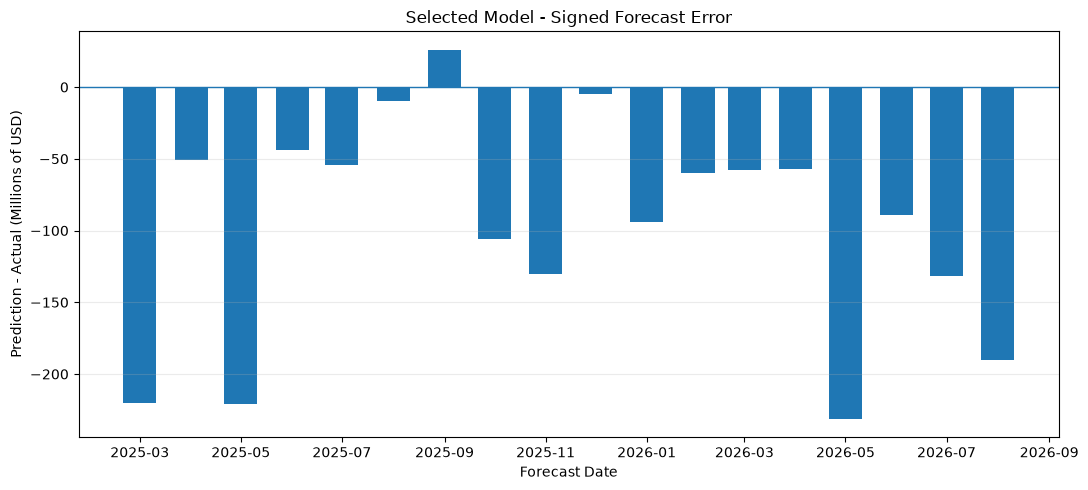

Saved: C:\Users\momo8\Desktop\electronic-components-planning\reports\figures\05_selected_model_signed_error.png


In [10]:
fig, ax = plt.subplots(
    figsize=(11, 5)
)

ax.bar(
    selected_predictions[
        "forecast_date"
    ],
    selected_predictions[
        "error"
    ],
    width=20,
)

ax.axhline(
    0,
    linewidth=1,
)

ax.set_title(
    "Selected Model - Signed Forecast Error"
)
ax.set_xlabel("Forecast Date")
ax.set_ylabel(
    "Prediction - Actual (Millions of USD)"
)
ax.grid(
    axis="y",
    alpha=0.25,
)

fig.tight_layout()

figure_path = (
    REPORT_FIGURE_DIR
    / "05_selected_model_signed_error.png"
)

fig.savefig(
    figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print("Saved:", figure_path)


### 輸出解讀

Signed Error 圖顯示：

- 幾乎所有柱子都位於 0 以下。
- 只有 2025-09 出現一個小幅正值 **+26**。
- 最大負 Error 約落在：
  - 2026-05：**-231**
  - 2025-05：**-221**
  - 2025-03：**-220**
  - 2026-08：**-190**

**白話解讀：**

Under-Forecast 並不是由一兩個極端月份造成，而是貫穿大部分 Validation Period。

因此 Last Value 的主要限制可以清楚描述為：

> **在近期向上趨勢中，預測準確度整體仍高，但存在持續低估需求的方向性 Bias。**

**下一步：**整理 18 筆 Absolute Percentage Error 的歷史分布。


## Step 11｜建立 Historical Absolute Error Distribution

### 這一格要做什麼？

對 18 筆 Absolute Percentage Error 計算：

- Median
- 75th percentile
- 80th percentile
- 90th percentile
- Maximum

### 為什麼不用常態分布直接建立 95% Interval？

目前只有 18 筆 out-of-sample errors，而且沒有證據支持 Error 服從常態分布。

因此只描述實際 Backtest 中觀察到的 Error Distribution，不建立虛假的精確 Confidence Interval。


In [11]:
absolute_pct_errors = (
    selected_predictions[
        "absolute_percentage_error"
    ].to_numpy(dtype=float)
)

error_distribution = pd.DataFrame(
    {
        "statistic": [
            "Median APE",
            "75th percentile APE",
            "80th percentile APE",
            "90th percentile APE",
            "Maximum APE",
        ],
        "value_pct": [
            np.percentile(
                absolute_pct_errors,
                50,
            ),
            np.percentile(
                absolute_pct_errors,
                75,
            ),
            np.percentile(
                absolute_pct_errors,
                80,
            ),
            np.percentile(
                absolute_pct_errors,
                90,
            ),
            np.max(
                absolute_pct_errors
            ),
        ],
    }
)

display(
    error_distribution.round(2)
)


,statistic,value_pct
0,Median APE,1.35
1,75th percentile APE,2.42
2,80th percentile APE,2.96
3,90th percentile APE,4.18
4,Maximum APE,4.29


### 輸出解讀

Historical Absolute Percentage Error：

| Statistic | APE |
|---|---:|
| Median | **1.35%** |
| 75th percentile | **2.42%** |
| 80th percentile | **2.96%** |
| 90th percentile | **4.18%** |
| Maximum | **4.29%** |

### 白話解讀

18 筆歷史 Backtest 中：

- 一半的 Forecast 絕對誤差不超過約 **1.35%**
- 約 80% 的 Historical Errors 不超過約 **2.96%**
- 最大觀察誤差為 **4.29%**

這說明 Last Value 的近期誤差通常不大，但仍存在少數 4% 左右的月份。

### 限制

`80th percentile = 2.96%` 只描述目前這 18 筆 Historical Backtest。

不能說：

> 未來有 80% 機率誤差一定低於 2.96%。

**下一步：**用 2.96% 建立簡單、透明的 Planning Reference Range。


## Step 12｜建立 80th Percentile Planning Reference

### 這一格要做什麼？

使用：

`80th percentile APE = Historical Error Buffer`

建立：

- Lower Planning Reference
- Point Forecast
- Upper Planning Reference

公式：

`Lower = Forecast × (1 - Buffer)`

`Upper = Forecast × (1 + Buffer)`

### 為什麼稱為 Planning Reference？

這只是將歷史 Backtest Error Scale 套到目前點預測，讓 Planning 情境不只剩一個單一數字。

它不是正式 Prediction Interval。


In [12]:
planning_buffer_pct = float(
    np.percentile(
        absolute_pct_errors,
        80,
    )
)

planning_buffer_rate = (
    planning_buffer_pct / 100
)

planning_reference = (
    final_forecast[
        [
            "date",
            "selected_forecast",
        ]
    ]
    .copy()
)

planning_reference[
    "lower_planning_reference"
] = (
    planning_reference[
        "selected_forecast"
    ]
    * (
        1 - planning_buffer_rate
    )
)

planning_reference[
    "upper_planning_reference"
] = (
    planning_reference[
        "selected_forecast"
    ]
    * (
        1 + planning_buffer_rate
    )
)

planning_reference = (
    planning_reference[
        [
            "date",
            "lower_planning_reference",
            "selected_forecast",
            "upper_planning_reference",
        ]
    ]
)

print(
    "80th percentile historical absolute error:",
    f"{planning_buffer_pct:.2f}%",
)

display(
    planning_reference.round(
        {
            "lower_planning_reference": 2,
            "selected_forecast": 2,
            "upper_planning_reference": 2,
        }
    )
)


80th percentile historical absolute error: 2.96%


,date,lower_planning_reference,selected_forecast,upper_planning_reference
0,2026-09-01,5598.27,5769.0,5939.73
1,2026-10-01,5598.27,5769.0,5939.73
2,2026-11-01,5598.27,5769.0,5939.73


### 輸出解讀

實際 Historical Error Buffer：

```text
80th percentile historical absolute error: 2.96%
```

Final Forecast 每個月都是 **5,769 百萬美元**，因此 Planning Reference 為：

| Month | Lower | Point Forecast | Upper |
|---|---:|---:|---:|
| 2026-09 | **5,598.27** | **5,769.00** | **5,939.73** |
| 2026-10 | **5,598.27** | **5,769.00** | **5,939.73** |
| 2026-11 | **5,598.27** | **5,769.00** | **5,939.73** |

### 白話解讀

若只以近期 Backtest 的 80th percentile Absolute Error 作為簡單參考，5,769 的點預測可搭配約：

**5,598 ～ 5,940 百萬美元**

的 planning reference range。

### 重要限制：目前 Error 並不對稱

18 筆中有 **17 筆 Under-Forecast**，因此實際 Error Distribution 明顯偏向低估需求。

目前這個 ±2.96% Range 是刻意保持簡單的對稱式參考，**並沒有修正 Under-Forecast Bias**。

所以在後續 Capacity / Fulfillment Scenario 中，Upper Reference **5,939.73** 比 Lower Reference 更值得作為需求壓力情境參考。

仍不能說：

> 未來有 80% 機率落在 5,598～5,940。

**下一步：**確認 Last Value 相對第二名 Holt-Winters 的優勢到底有多大。


## Step 13｜比較最佳模型與第二名模型

### 這一格要做什麼？

比較：

- Best Model WAPE
- Runner-up WAPE
- Absolute WAPE Difference
- Relative WAPE Improvement

### 為什麼重要？

模型排名第一不等於優勢很大。

如果第一名和第二名只差一點，較準確的描述應是「略優」，而不是「大幅勝出」。


In [13]:
ranked_models = (
    model_summary
    .sort_values("wape_pct")
    .reset_index(drop=True)
)

best = ranked_models.iloc[0]
runner_up = ranked_models.iloc[1]

absolute_wape_difference = float(
    runner_up["wape_pct"]
    - best["wape_pct"]
)

relative_wape_improvement = float(
    absolute_wape_difference
    / runner_up["wape_pct"]
    * 100
)

top_model_comparison = pd.DataFrame(
    {
        "metric": [
            "Best model",
            "Best WAPE",
            "Runner-up model",
            "Runner-up WAPE",
            "Absolute WAPE difference",
            "Relative WAPE improvement",
        ],
        "value": [
            str(best["model"]),
            f"{best['wape_pct']:.3f}%",
            str(runner_up["model"]),
            f"{runner_up['wape_pct']:.3f}%",
            f"{absolute_wape_difference:.3f} percentage points",
            f"{relative_wape_improvement:.2f}%",
        ],
    }
)

display(top_model_comparison)


,metric,value
0,Best model,last_value
1,Best WAPE,1.851%
2,Runner-up model,holt_winters
3,Runner-up WAPE,1.991%
4,Absolute WAPE difference,0.141 percentage points
5,Relative WAPE improvement,7.07%


### 輸出解讀

實際比較：

| Metric | Result |
|---|---|
| Best Model | **Last Value** |
| Best WAPE | **1.851%** |
| Runner-up | **Holt-Winters** |
| Runner-up WAPE | **1.991%** |
| Absolute Difference | **0.141 percentage points** |
| Relative Improvement | **7.07%** |

### 白話解讀

Last Value 的 WAPE 比 Holt-Winters 低 **0.141 個百分點**。

以 Holt-Winters 的 WAPE 作為比較基準，Last Value 的相對誤差改善約 **7.07%**。

這代表 Last Value 的確是 Backtest 第一名，但兩者絕對差距並不大。

因此最精準的描述是：

> **Last Value 在近期 Rolling Backtest 中略優於 Holt-Winters。**

不適合描述成：

> **Last Value 大幅超越 Holt-Winters。**

此外，Last Value 雖然整體 WAPE 較低，但 Bias Analysis 顯示它有明顯 Under-Forecast 傾向，因此「最低 WAPE」與「最少方向性偏差」並不是同一件事。

**下一步：**整合 Accuracy、Bias、Worst Horizon、Worst Fold 與 Error Buffer。


## Step 14｜建立 Forecast Evaluation Summary

### 這一格要做什麼？

整理：

- Selected Model
- Pooled WAPE
- Aggregate Bias
- Over / Under Count
- Worst Horizon
- Worst Fold
- Maximum Single-Month APE
- 80th Percentile APE
- Best vs Runner-up WAPE Gap

### 為什麼需要 Summary？

04 回答「選哪個模型」。

05 Summary 回答：

> 「這個模型雖然是最佳方法，但使用時有哪些已知限制與不確定性？」


In [14]:
selected_model_summary = (
    model_summary.loc[
        model_summary["model"]
        .eq(best_model_name)
    ]
    .iloc[0]
)

worst_horizon = (
    horizon_bias
    .sort_values(
        "mape_pct",
        ascending=False,
    )
    .iloc[0]
)

maximum_ape = float(
    selected_predictions[
        "absolute_percentage_error"
    ].max()
)

evaluation_summary = pd.DataFrame(
    {
        "metric": [
            "Selected Model",
            "Pooled Backtest WAPE",
            "Aggregate Bias",
            "Over-Forecast Count",
            "Under-Forecast Count",
            "Worst Horizon by MAPE",
            "Worst Fold by WAPE",
            "Worst Fold WAPE",
            "Maximum Single-Month APE",
            "80th Percentile APE",
            "Best vs Runner-up WAPE Gap",
        ],
        "value": [
            best_model_name,
            (
                f"{selected_model_summary['wape_pct']:.3f}%"
            ),
            f"{aggregate_bias_pct:.2f}%",
            int(
                direction_counts[
                    "Over-Forecast"
                ]
            ),
            int(
                direction_counts[
                    "Under-Forecast"
                ]
            ),
            int(
                worst_horizon[
                    "horizon"
                ]
            ),
            int(
                worst_fold["fold"]
            ),
            f"{worst_fold['wape_pct']:.3f}%",
            f"{maximum_ape:.2f}%",
            f"{planning_buffer_pct:.2f}%",
            (
                f"{absolute_wape_difference:.3f} pp"
            ),
        ],
    }
)

display(evaluation_summary)


,metric,value
0,Selected Model,last_value
1,Pooled Backtest WAPE,1.851%
2,Aggregate Bias,-1.80%
3,Over-Forecast Count,1
4,Under-Forecast Count,17
5,Worst Horizon by MAPE,3
6,Worst Fold by WAPE,1
7,Worst Fold WAPE,3.221%
8,Maximum Single-Month APE,4.29%
9,80th Percentile APE,2.96%


### 輸出解讀

Forecast Evaluation Summary：

| Metric | Result |
|---|---:|
| Selected Model | **last_value** |
| Pooled Backtest WAPE | **1.851%** |
| Aggregate Bias | **-1.80%** |
| Over-Forecast Count | **1** |
| Under-Forecast Count | **17** |
| Worst Horizon | **H3** |
| Worst Fold | **Fold 1** |
| Worst Fold WAPE | **3.221%** |
| Maximum Single-Month APE | **4.29%** |
| 80th Percentile APE | **2.96%** |
| Best vs Runner-up Gap | **0.141 pp** |

## 最終白話結論

Last Value 在近期 18 個 out-of-sample Validation Months 中具有最低的整體 WAPE，因此仍是目前最合理的點預測方法。

但 Evaluation 顯示三個重要限制：

### 1. 存在明顯 Under-Forecast Bias

17 / 18 筆 Prediction 都低於 Actual，Aggregate Bias = **-1.80%**。

### 2. Horizon 越遠，低估程度越明顯

H3：

- MAPE = **2.58%**
- Aggregate Bias = **-2.61%**
- 6 / 6 全部 Under-Forecast

因此 3-month ahead Forecast 應比 1-month ahead 保留更多不確定性。

### 3. Best Model 優勢並不巨大

Last Value WAPE 只比 Holt-Winters 低 **0.141 percentage points**，因此模型選擇證據支持 Last Value，但不是壓倒性差距。

### Planner 使用方式

目前最合理的使用方式是：

> **Last Value 作為 Point Forecast，同時保留 Historical Error Buffer，並在需求壓力 Scenario 中特別關注上方需求風險。**

不能把：

- WAPE 1.851%
- 80th percentile APE 2.96%
- Maximum APE 4.29%

解讀成未來保證範圍或風險機率。

**下一步：**將 Forecast、Upper Planning Reference、Capacity 與 Customer Order Scenario 接到 06 Order Fulfillment Simulator。


## Step 15｜保存 05 Evaluation 結果

### 這一格要做什麼？

保存：

- Selected Model Backtest Errors
- Bias Summary
- Horizon Bias
- Fold Evaluation
- Worst Predictions
- Error Distribution
- Planning Reference
- Top Model Comparison
- Evaluation Summary

### 為什麼要保存？

06 可以直接使用：

- Final Forecast
- Planning Reference
- Forecast Evaluation Summary

建立 Demand / Capacity / Delivery Scenario，而不需要重新計算 Forecast Error。


In [15]:
output_files = {
    "selected_model_backtest_errors.csv": (
        selected_predictions
    ),
    "forecast_bias_summary.csv": (
        overall_bias_summary
    ),
    "forecast_horizon_bias.csv": (
        horizon_bias
    ),
    "forecast_fold_evaluation.csv": (
        fold_evaluation
    ),
    "forecast_worst_predictions.csv": (
        worst_predictions
    ),
    "forecast_error_distribution.csv": (
        error_distribution
    ),
    "forecast_planning_reference.csv": (
        planning_reference
    ),
    "forecast_top_model_comparison.csv": (
        top_model_comparison
    ),
    "forecast_evaluation_summary.csv": (
        evaluation_summary
    ),
}

for file_name, dataframe in (
    output_files.items()
):

    output_path = (
        REPORT_TABLE_DIR
        / file_name
    )

    dataframe.to_csv(
        output_path,
        index=False,
    )

    print("Saved:", file_name)


Saved: selected_model_backtest_errors.csv
Saved: forecast_bias_summary.csv
Saved: forecast_horizon_bias.csv
Saved: forecast_fold_evaluation.csv
Saved: forecast_worst_predictions.csv
Saved: forecast_error_distribution.csv
Saved: forecast_planning_reference.csv
Saved: forecast_top_model_comparison.csv
Saved: forecast_evaluation_summary.csv


### 輸出解讀

九份 Evaluation Output 全部成功保存：

```text
selected_model_backtest_errors.csv
forecast_bias_summary.csv
forecast_horizon_bias.csv
forecast_fold_evaluation.csv
forecast_worst_predictions.csv
forecast_error_distribution.csv
forecast_planning_reference.csv
forecast_top_model_comparison.csv
forecast_evaluation_summary.csv
```

## 05 完成的分析鏈

`04 Selected Forecast Model`
→ **逐筆 Forecast Error**
→ **Overall Bias**
→ **Horizon Bias**
→ **Fold Stability**
→ **Worst Monthly Errors**
→ **Actual vs Prediction**
→ **Signed Error Timeline**
→ **Historical Error Distribution**
→ **Planning Reference**
→ **Best vs Runner-up Comparison**
→ **Forecast Evaluation Summary**

## 05 最重要的發現

截至目前的近期 Rolling Backtest：

- Last Value pooled WAPE = **1.851%**
- Aggregate Bias = **-1.80%**
- 17 / 18 次 Under-Forecast
- H3 Bias = **-2.61%**
- Maximum APE = **4.29%**
- 80th percentile APE = **2.96%**
- Last Value 僅比 Holt-Winters 低 **0.141 pp WAPE**

因此最適合的結論不是單純：

> 「Last Value 很準。」

而是：

> **Last Value 在近期 Backtest 中具有最低整體誤差，但在上升需求環境中存在明顯低估 Bias，且較遠 Horizon 的風險更高。**

## 下一步

`06_order_fulfillment_simulator.ipynb`

最後一階段將把：

**Point Forecast + Upper Planning Reference + Capacity + Existing Load + Synthetic Customer Orders**

轉成：

- Available Capacity
- Order Allocation
- Requested Due Date
- Feasible Commit Date
- On-Time / At-Risk / Late
- Demand What-if Scenario

其中 Capacity 與 Customer Order Book 必須清楚標示為 **Synthetic Planning Scenario**，不能暗示為 ASE 內部資料。
